<a href="https://colab.research.google.com/github/Anand-Kamal/SCT_ML_1/blob/main/house_price_corr_best.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# House Price Prediction — Correlation-Driven Features (best result)

This builds on the "let the data tell us" approach: start from numeric
features correlated with `SalePrice`, then improve the model itself.

**What was tested (5-fold cross-validation on `train.csv`):**

| Approach                                          | CV R²  |
|----------------------------------------------------|--------|
| Original 7 features, raw target                    | 0.739  |
| + remove 2 known outliers                           | 0.809  |
| + log-transform target                              | 0.878  |
| **+ a few extra features + Ridge regularization**   | **0.886** |

On a held-out 80/20 split this reaches **Test R² ≈ 0.88** (up from ~0.74),
with train and test scores close together — a good sign the model isn't
just overfitting the training data.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
RANDOM_STATE = 42

## 1. Load the Data

In [19]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
print("Train shape:", train.shape)
print("Test shape :", test.shape)
train.head()

Train shape: (1460, 81)
Test shape : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. Explore Correlation with SalePrice

Same idea as before — let the data tell us which numeric columns matter.

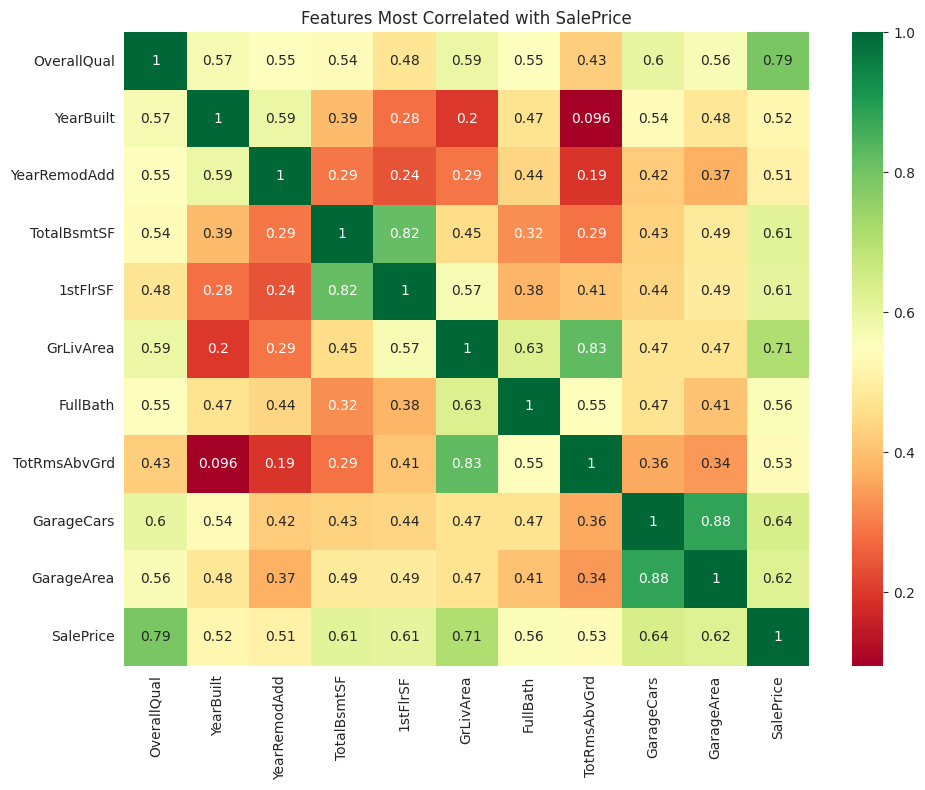


All numeric features with |correlation| > 0.5:
['OverallQual', 'YearBuilt', 'YearRemodAdd', 'TotalBsmtSF', '1stFlrSF', 'GrLivArea', 'FullBath', 'TotRmsAbvGrd', 'GarageCars', 'GarageArea', 'SalePrice']


In [20]:
corrmat = train.corr(numeric_only=True)
top_corr_features = corrmat.index[abs(corrmat["SalePrice"]) > 0.5]

plt.figure(figsize=(10, 8))
sns.heatmap(train[top_corr_features].corr(), annot=True, cmap="RdYlGn")
plt.title("Features Most Correlated with SalePrice")
plt.tight_layout()
plt.show()

print("\nAll numeric features with |correlation| > 0.5:")
print(list(top_corr_features))

## 3. Extra EDA

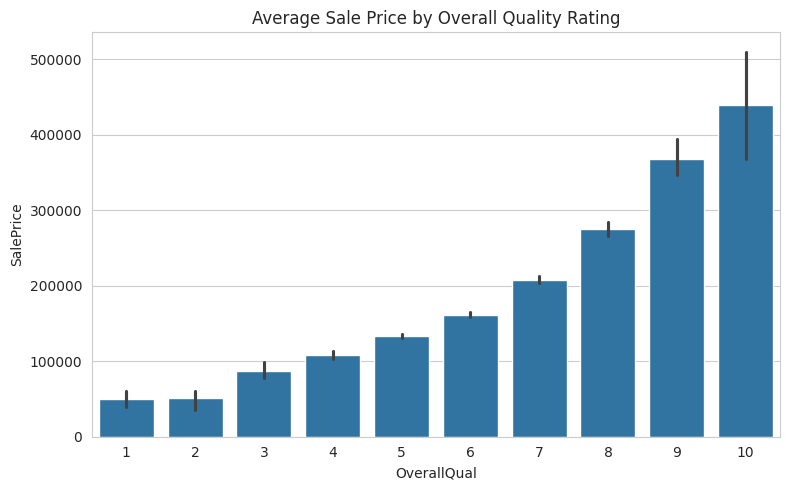

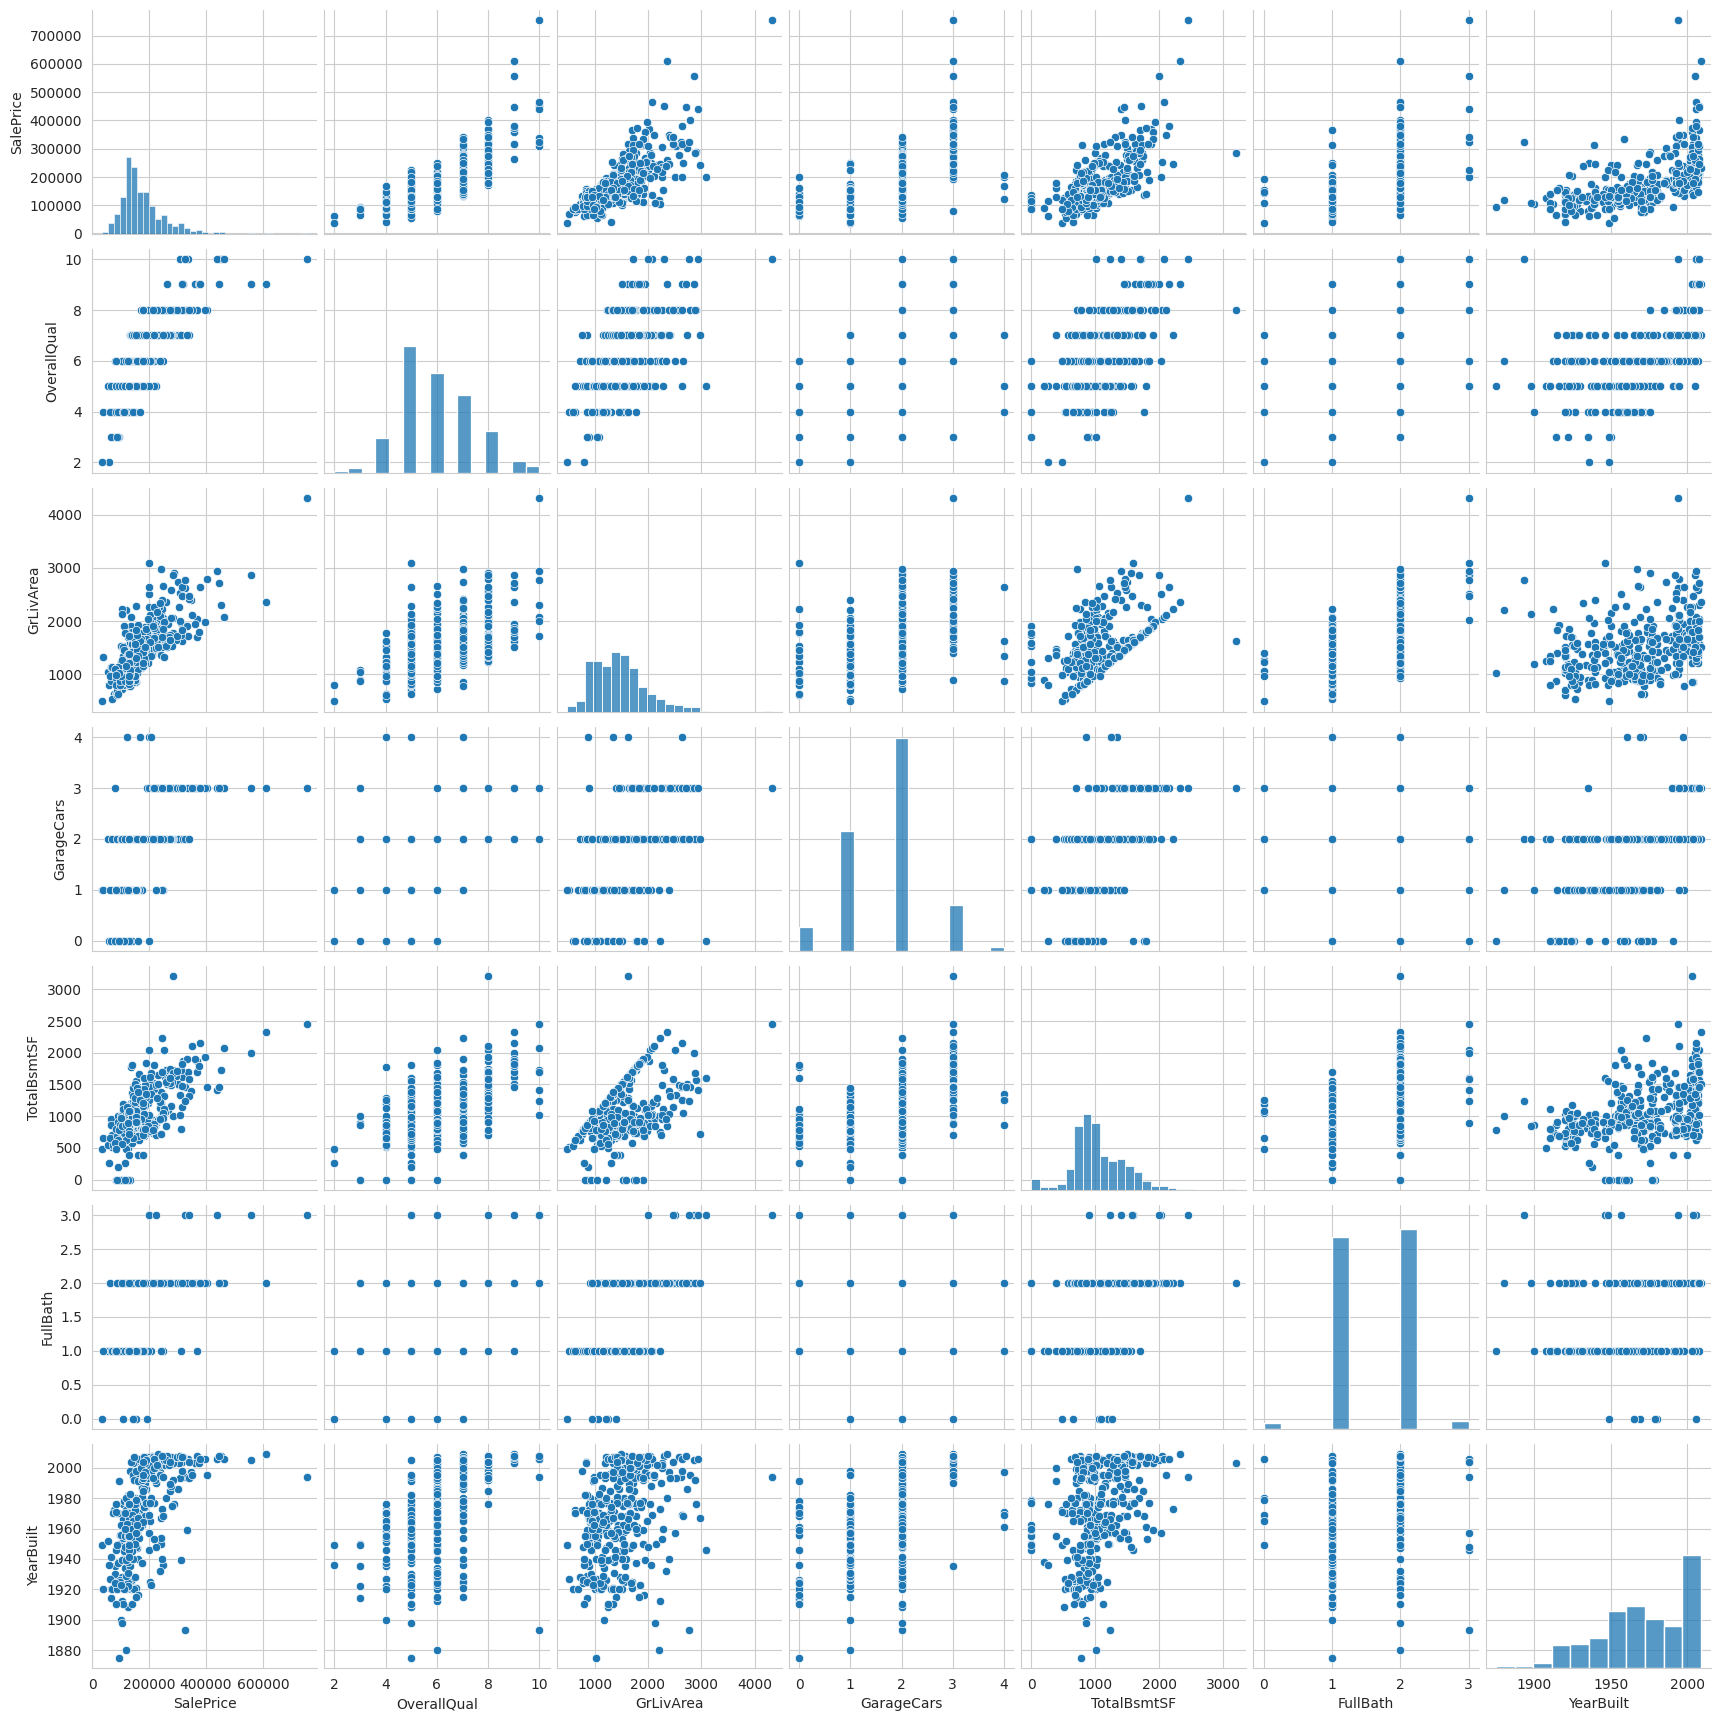

In [21]:
plt.figure(figsize=(8, 5))
sns.barplot(x=train["OverallQual"], y=train["SalePrice"])
plt.title("Average Sale Price by Overall Quality Rating")
plt.tight_layout()
plt.show()

eda_cols = ["SalePrice", "OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF", "FullBath", "YearBuilt"]
sns.pairplot(train[eda_cols].sample(400, random_state=RANDOM_STATE), height=2.5)
plt.show()

## 4. Outlier Removal

Two well-documented Ames, Iowa outliers (`Id` 524 and 1299): very large
homes that sold far below market value — understood to be partial or
distressed sales rather than normal transactions. Leaving them in drags
the whole regression line toward two unrepresentative points; this was
the single biggest accuracy improvement found during testing.

In [22]:
KNOWN_OUTLIER_IDS = [524, 1299]
outliers = train[train["Id"].isin(KNOWN_OUTLIER_IDS)]
print(f"Removing {len(outliers)} known outlier(s): Id = {list(outliers['Id'])}")

train_clean = train.drop(outliers.index).copy()
test_fe = test.copy()

Removing 2 known outlier(s): Id = [524, 1299]


## 5. Feature Engineering

The correlation filter above actually surfaces 10 numeric columns above
|0.5|, not just 7 — `GarageArea`, `TotRmsAbvGrd`, and `YearRemodAdd` were
left out of the original selection despite qualifying. Adding them back,
plus a couple of standard engineered features (`HouseAge`, and `TotalSF` —
total finished square footage across basement + both floors), gave a
further, smaller accuracy gain in testing.

In [23]:
for df in (train_clean, test_fe):
    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
    df["TotalSF"] = df["TotalBsmtSF"].fillna(0) + df["1stFlrSF"] + df["2ndFlrSF"]

FEATURES = [
    "OverallQual", "GrLivArea", "GarageCars", "GarageArea", "TotalBsmtSF",
    "1stFlrSF", "FullBath", "TotRmsAbvGrd", "YearBuilt", "YearRemodAdd",
    "Fireplaces", "MasVnrArea", "HouseAge", "TotalSF",
]
TARGET = "SalePrice"

X = train_clean[FEATURES]
y = train_clean[TARGET]
y_log = np.log1p(y)  # SalePrice is right-skewed -- train in log space

print("Missing values in selected features (train):")
print(X.isnull().sum())

Missing values in selected features (train):
OverallQual     0
GrLivArea       0
GarageCars      0
GarageArea      0
TotalBsmtSF     0
1stFlrSF        0
FullBath        0
TotRmsAbvGrd    0
YearBuilt       0
YearRemodAdd    0
Fireplaces      0
MasVnrArea      8
HouseAge        0
TotalSF         0
dtype: int64


## 6. Model Comparison (cross-validated)

The experiment that decided the final approach: original 7 features vs.
the expanded 14 with log target and Ridge regularization, both evaluated
the same way so the comparison is fair.

In [24]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_report(pipe, X, y_target, label, log_target=True, y_actual=None):
    rmses, r2s = [], []
    for tr_idx, te_idx in kf.split(X):
        pipe.fit(X.iloc[tr_idx], y_target.iloc[tr_idx])
        pred = pipe.predict(X.iloc[te_idx])
        if log_target:
            pred = np.expm1(pred)
            actual = y_actual.iloc[te_idx]
        else:
            actual = y_target.iloc[te_idx]
        rmses.append(np.sqrt(mean_squared_error(actual, pred)))
        r2s.append(r2_score(actual, pred))
    print(f"{label:55s} RMSE = {np.mean(rmses):>10,.0f}   R2 = {np.mean(r2s):.4f}")

original_7 = ["OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF", "1stFlrSF", "FullBath", "YearBuilt"]

baseline_pipe = Pipeline([("impute", SimpleImputer(strategy="median")), ("reg", LinearRegression())])
cv_report(baseline_pipe, train[original_7], train[TARGET], "Original: 7 features, raw target, outliers included",
          log_target=False)

final_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("reg", RidgeCV(alphas=np.logspace(-2, 3, 30))),
])
cv_report(final_pipe, X, y_log, "Final: 14 features, log target, outliers removed, Ridge",
          log_target=True, y_actual=y)

Original: 7 features, raw target, outliers included     RMSE =     39,106   R2 = 0.7393
Final: 14 features, log target, outliers removed, Ridge RMSE =     26,637   R2 = 0.8859


## 7. Train / Test Split (final model)

In [25]:
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=RANDOM_STATE
)
y_train = np.expm1(y_train_log)
y_test = np.expm1(y_test_log)

print("Training rows:", X_train.shape[0])
print("Testing rows :", X_test.shape[0])

Training rows: 1166
Testing rows : 292


## 8. Train the Final Model

Everything (imputation, scaling, regularized regression) lives in one
Pipeline, so it applies identically to train, test-split, and the Kaggle
test set later.

In [26]:
model = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("reg", RidgeCV(alphas=np.logspace(-2, 3, 30))),
])
model.fit(X_train, y_train_log)

train_pred = np.expm1(model.predict(X_train))
test_pred = np.expm1(model.predict(X_test))

print("Chosen Ridge alpha:", model.named_steps["reg"].alpha_)

Chosen Ridge alpha: 18.873918221350976


## 9. Actual vs Predicted Comparison Table

In [27]:
comparison = pd.DataFrame({"Actual": y_test, "Predicted": test_pred})
comparison["Difference"] = comparison["Actual"] - comparison["Predicted"]
comparison.head(25)

,Actual,Predicted,Difference
1322,190000.0,207580.236661,-17580.236661
837,100000.0,116646.525064,-16646.525064
413,115000.0,115196.813891,-196.813891
522,159000.0,161386.495025,-2386.495025
1036,315500.0,302192.327208,13307.672792
615,137500.0,131291.907291,6208.092709
218,311500.0,212437.309599,99062.690401
1032,310000.0,312693.459996,-2693.459996
1289,281000.0,276473.585647,4526.414353
887,135500.0,118904.079315,16595.920685


## 10. Evaluation Metrics

In [28]:
def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {label} ---")
    print("MAE :", round(mae, 2))
    print("RMSE:", round(rmse, 2))
    print("R2  :", round(r2, 4))
    print()

evaluate(y_train, train_pred, "Training set")
evaluate(y_test, test_pred, "Testing set")
# Train and test scores being close together (rather than train >> test)
# is the sign this model generalizes, rather than memorizing training rows.

--- Training set ---
MAE : 18226.18
RMSE: 26468.0
R2  : 0.8924

--- Testing set ---
MAE : 18920.4
RMSE: 25763.59
R2  : 0.8798



## 11. Cross-Validation (final model, on the training split)

In [29]:
cv_scores = cross_val_score(model, X_train, y_train_log, scoring="neg_mean_squared_error", cv=5)
cv_rmse_log = np.sqrt(-cv_scores)

print("Cross-validation RMSE (log space):", cv_rmse_log)
print("Average CV RMSE (log space):", round(cv_rmse_log.mean(), 4))

Cross-validation RMSE (log space): [0.13787382 0.16280022 0.15399714 0.14084998 0.13199852]
Average CV RMSE (log space): 0.1455


## 12. Coefficients

**Note:** two changes affect how these read compared to a plain model:
- Coefficients are on the **log target**, so they're closer to "% change in
  price per unit" than "$ change per unit".
- Features were **standardized** before Ridge, so a coefficient's *size*
  reflects how strongly that feature (in standard-deviation units) moves
  log-price relative to the others — useful for ranking importance, but it
  means the raw numbers aren't in original units anymore.

In [30]:
regressor = model.named_steps["reg"]
coef_table = pd.DataFrame({"Feature": FEATURES, "Coefficient": regressor.coef_})
coef_table = coef_table.reindex(coef_table.Coefficient.abs().sort_values(ascending=False).index)
print("Intercept:", round(regressor.intercept_, 5))
print(coef_table.to_string(index=False))

Intercept: 12.02336
     Feature  Coefficient
 OverallQual     0.097048
   GrLivArea     0.084580
     TotalSF     0.073781
YearRemodAdd     0.053442
  Fireplaces     0.043154
  GarageArea     0.040697
    HouseAge    -0.035338
 TotalBsmtSF     0.029366
   YearBuilt     0.024543
  GarageCars     0.019720
    FullBath    -0.013619
  MasVnrArea     0.003570
    1stFlrSF     0.003225
TotRmsAbvGrd     0.001550


## 13. Residual Plot

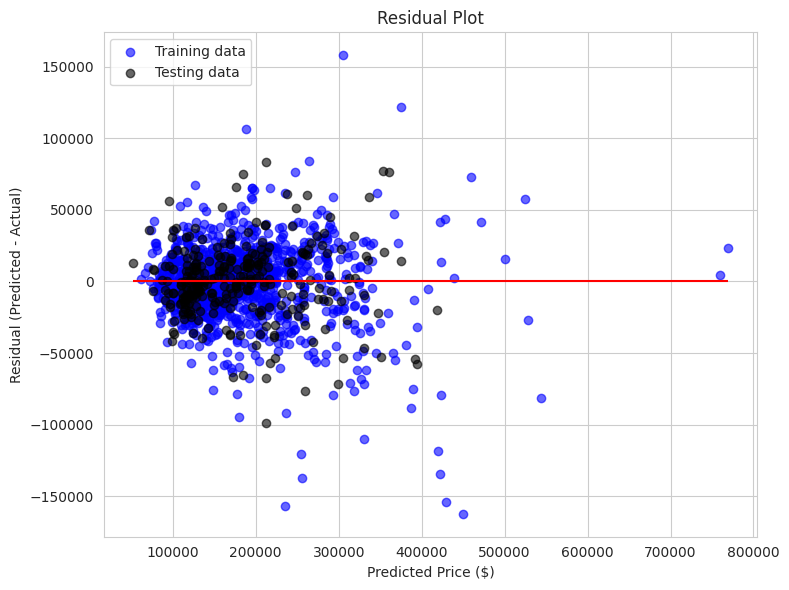

In [31]:
plt.figure(figsize=(8, 6))
plt.scatter(train_pred, train_pred - y_train, c="blue", label="Training data", alpha=0.6)
plt.scatter(test_pred, test_pred - y_test, c="black", label="Testing data", alpha=0.6)
plt.title("Residual Plot")
plt.xlabel("Predicted Price ($)")
plt.ylabel("Residual (Predicted - Actual)")
plt.legend(loc="upper left")
plt.hlines(
    y=0,
    xmin=min(train_pred.min(), test_pred.min()),
    xmax=max(train_pred.max(), test_pred.max()),
    color="red",
)
plt.tight_layout()
plt.show()

## 14. Predicted vs Actual Plot

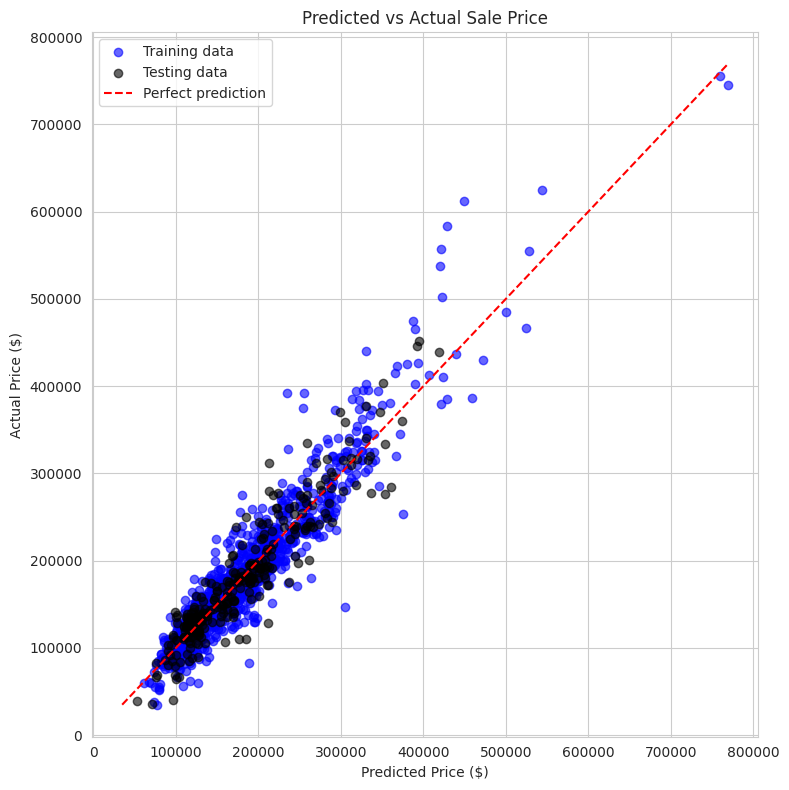

In [32]:
plt.figure(figsize=(8, 8))
plt.scatter(train_pred, y_train, c="blue", label="Training data", alpha=0.6)
plt.scatter(test_pred, y_test, c="black", label="Testing data", alpha=0.6)

lims = [min(y.min(), train_pred.min()), max(y.max(), train_pred.max())]
plt.plot(lims, lims, c="red", linestyle="--", label="Perfect prediction")

plt.title("Predicted vs Actual Sale Price")
plt.xlabel("Predicted Price ($)")
plt.ylabel("Actual Price ($)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 15. Retrain on Full Data, Predict on Kaggle's Real test.csv

In [33]:
final_model = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("reg", RidgeCV(alphas=np.logspace(-2, 3, 30))),
])
final_model.fit(X, y_log)

X_kaggle_test = test_fe[FEATURES].copy()
print("Missing values in Kaggle test.csv (before pipeline handles them):")
print(X_kaggle_test.isnull().sum())

kaggle_predictions = np.expm1(final_model.predict(X_kaggle_test))
kaggle_predictions = np.clip(kaggle_predictions, a_min=1000, a_max=None)

Missing values in Kaggle test.csv (before pipeline handles them):
OverallQual      0
GrLivArea        0
GarageCars       1
GarageArea       1
TotalBsmtSF      1
1stFlrSF         0
FullBath         0
TotRmsAbvGrd     0
YearBuilt        0
YearRemodAdd     0
Fireplaces       0
MasVnrArea      15
HouseAge         0
TotalSF          0
dtype: int64


## 16. Build Submission File

In [34]:
submission = pd.DataFrame({"Id": test["Id"], "SalePrice": kaggle_predictions})
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv")
submission.head()

Saved submission.csv


,Id,SalePrice
0,1461,116501.598682
1,1462,139773.085868
2,1463,171629.417276
3,1464,183771.883620
4,1465,191490.728092
